## 1. Loading Required Packages

In [6]:
# Standard libraries
import sys
sys.path.append('../../')

import itertools

# Data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# FinRL and stable_baselines3 for machine learning and trading
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_primo_trading.env_primorl import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3 import A2C, DDPG, PPO, SAC, TD3
from stable_baselines3.common.logger import configure

# Configuration files and helper functions from FinRL
from finrl.config import INDICATORS, FUNDAMENTAL_INDICATORS
from finrl.main import check_and_make_directories

# Enabling chart display within Jupyter notebook
%matplotlib inline

TRAINED_MODEL_DIR = 'files/models_PORTFOLIO'
RESULTS_DIR = 'files/results_PORTFOLIO'
DATA_DIR = 'files/data_PORTFOLIO'

# Checking and creating directories
check_and_make_directories([TRAINED_MODEL_DIR, DATA_DIR])

## 2. Data Retrieval

In [7]:
start_date = "2020-07-01"
end_date = "2025-05-31"

# Training and trading intervals
TRAIN_START_DATE = '2020-07-01'
TRAIN_END_DATE = '2024-07-31'
TRADE_START_DATE = '2024-08-01'
TRADE_END_DATE = '2025-05-31'

In [8]:
# List of stocks
stocks = ["AAPL", "NFLX", "MSFT", "CRM", "AMZN"]

# Loading data for each stock
for stock in stocks:
    file_path = f'data/{stock}_{start_date}_{end_date}_gpt.csv'
    df_name = f'gpt_predictions_{stock.lower()}'
    
    # Load CSV file
    globals()[df_name] = pd.read_csv(file_path)
    
    # Rename 'Date' column to 'date'
    globals()[df_name] = globals()[df_name].rename(columns={'Date': 'date'})
    
    # Add 'tic' column with stock symbol
    globals()[df_name]['tic'] = stock

In [9]:
gpt_predictions_aapl.head()

,date,Adj Close Price,Returns,Bin Label,News Relevance,Sentiment,Price Impact Potential,Trend Direction,Earnings Impact,Investor Confidence,Risk Profile Change,Prompt,tic
0,2020-07-02,88.485001,0.000000,U0,2.0,1.0,1.0,1.0,1.0,1.0,0.0,Human: \n [SYSTEM PROMPT]\n You are a se...,AAPL
1,2020-07-06,90.852005,0.026750,U3,1.0,0.0,-1.0,0.0,0.0,-1.0,-1.0,Human: \n [SYSTEM PROMPT]\n You are a se...,AAPL
2,2020-07-07,90.570107,-0.003103,D1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,Human: \n [SYSTEM PROMPT]\n You are a se...,AAPL
3,2020-07-08,92.679504,0.023290,U3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Human: \n [SYSTEM PROMPT]\n You are a se...,AAPL
4,2020-07-09,93.078041,0.004300,U1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Human: \n [SYSTEM PROMPT]\n You are a se...,AAPL


In [10]:
# Fetching all data
df_raw = YahooDownloader(start_date = TRAIN_START_DATE,
                         end_date = TRADE_END_DATE,
                         ticker_list = ["AAPL", "NFLX", "MSFT", "CRM", "AMZN"]).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (6175, 8)


In [11]:
df_raw.head()

,date,open,high,low,close,volume,tic,day
0,2020-07-01,88.485016,91.027496,91.839996,91.279999,110737200,AAPL,2
1,2020-07-01,143.934998,143.934998,144.750000,137.899506,127268000,AMZN,2
2,2020-07-01,190.223160,191.889999,192.820007,188.100006,4754600,CRM,2
3,2020-07-01,196.120117,204.699997,206.350006,203.139999,32061200,MSFT,2
4,2020-07-01,485.640015,485.640015,488.230011,454.000000,9705900,NFLX,2


## 3. Data Processing

In [12]:
fe = FeatureEngineer(use_technical_indicator=True,
                     tech_indicator_list = INDICATORS,
                     use_vix=True,
                     use_turbulence=True,
                     user_defined_feature = False)

processed = fe.preprocess_data(df_raw)

Successfully added technical indicators


[*********************100%***********************]  1 of 1 completed


Shape of DataFrame:  (1234, 8)
Successfully added vix
Successfully added turbulence index


In [13]:
# Creates a list of unique stock tickers from the 'tic' column of the 'processed' DataFrame.
list_ticker = processed["tic"].unique().tolist()

# Creates a list of dates between the earliest and latest dates in the 'processed' DataFrame, converting them to strings.
list_date = list(pd.date_range(processed['date'].min(), processed['date'].max()).astype(str))

# Creates combinations of all dates and stock tickers using the Cartesian product.
combination = list(itertools.product(list_date, list_ticker))

# Creates a new DataFrame 'processed_full' with columns "date" and "tic", containing all combinations of dates and stock tickers.
# Merges this DataFrame with the original 'processed' DataFrame based on the "date" and "tic" columns, using a 'left' join.
processed_full = pd.DataFrame(combination, columns=["date", "tic"]).merge(processed, on=["date", "tic"], how="left")

# Filters the 'processed_full' DataFrame to contain only those rows whose dates are present in the original 'processed' DataFrame.
processed_full = processed_full[processed_full['date'].isin(processed['date'])]

# Sorts the 'processed_full' DataFrame by date and stock ticker.
processed_full = processed_full.sort_values(['date', 'tic'])

# Replaces all missing values (NaN) with 0 in the 'processed_full' DataFrame.
processed_full = processed_full.fillna(0)

In [14]:
processed_full.head()

,date,tic,open,high,low,close,volume,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,vix,turbulence
0,2020-07-01,AAPL,88.485016,91.027496,91.839996,91.279999,110737200.0,2.0,0.0,92.586455,90.656046,100.0,66.666667,100.0,91.279999,91.279999,30.959999,0.0
1,2020-07-01,AMZN,143.934998,143.934998,144.750000,137.899506,127268000.0,2.0,0.0,92.586455,90.656046,100.0,66.666667,100.0,137.899506,137.899506,30.959999,0.0
2,2020-07-01,CRM,190.223160,191.889999,192.820007,188.100006,4754600.0,2.0,0.0,92.586455,90.656046,100.0,66.666667,100.0,188.100006,188.100006,30.959999,0.0
3,2020-07-01,MSFT,196.120117,204.699997,206.350006,203.139999,32061200.0,2.0,0.0,92.586455,90.656046,100.0,66.666667,100.0,203.139999,203.139999,30.959999,0.0
4,2020-07-01,NFLX,485.640015,485.640015,488.230011,454.000000,9705900.0,2.0,0.0,92.586455,90.656046,100.0,66.666667,100.0,454.000000,454.000000,30.959999,0.0


In [15]:
# Columns we want to keep from GPT predictions
columns_to_keep = ['date', 'News Relevance', 'Sentiment', 'Price Impact Potential', 
                   'Trend Direction', 'Earnings Impact', 'Investor Confidence', 'Risk Profile Change']

# Mapping for renaming columns
column_mapping = {
    'News Relevance': 'news_relevance',
    'Sentiment': 'sentiment',
    'Price Impact Potential': 'price_impact_potential',
    'Trend Direction': 'trend_direction',
    'Earnings Impact': 'earnings_impact',
    'Investor Confidence': 'investor_confidence',
    'Risk Profile Change': 'risk_profile_change'
}

# Preparing data for AAPL
gpt_data_aapl = gpt_predictions_aapl[columns_to_keep]
gpt_data_aapl = gpt_data_aapl.rename(columns=column_mapping)
gpt_data_aapl['tic'] = 'AAPL'

# Merging data only for AAPL rows
processed_full = processed_full.merge(gpt_data_aapl, on=['date', 'tic'], how='left')

# Filling NaN values with 0 only for new columns
new_columns = list(column_mapping.values())
processed_full[new_columns] = processed_full[new_columns].fillna(0)


In [16]:
# Mapping for renaming columns
column_mapping = {
    'News Relevance': 'news_relevance',
    'Sentiment': 'sentiment',
    'Price Impact Potential': 'price_impact_potential',
    'Trend Direction': 'trend_direction',
    'Earnings Impact': 'earnings_impact',
    'Investor Confidence': 'investor_confidence',
    'Risk Profile Change': 'risk_profile_change'
}

# Preparing data for NFLX
gpt_data_nflx = gpt_predictions_nflx[['date'] + list(column_mapping.keys())]
gpt_data_nflx = gpt_data_nflx.rename(columns=column_mapping)
gpt_data_nflx['tic'] = 'NFLX'

# Updating data only for NFLX rows
for column in column_mapping.values():
    processed_full.loc[processed_full['tic'] == 'NFLX', column] = processed_full.loc[processed_full['tic'] == 'NFLX'].merge(
        gpt_data_nflx[['date', 'tic', column]], 
        on=['date', 'tic'], 
        how='left'
    )[f'{column}_y'].fillna(processed_full[column])

In [17]:
# Mapping for renaming columns
column_mapping = {
    'News Relevance': 'news_relevance',
    'Sentiment': 'sentiment',
    'Price Impact Potential': 'price_impact_potential',
    'Trend Direction': 'trend_direction',
    'Earnings Impact': 'earnings_impact',
    'Investor Confidence': 'investor_confidence',
    'Risk Profile Change': 'risk_profile_change'
}

# Preparing data for MSFT
gpt_data_msft = gpt_predictions_msft[['date'] + list(column_mapping.keys())]
gpt_data_msft = gpt_data_msft.rename(columns=column_mapping)
gpt_data_msft['tic'] = 'MSFT'

# Updating data only for MSFT rows
for column in column_mapping.values():
    processed_full.loc[processed_full['tic'] == 'MSFT', column] = processed_full.loc[processed_full['tic'] == 'MSFT'].merge(
        gpt_data_msft[['date', 'tic', column]], 
        on=['date', 'tic'], 
        how='left'
    )[f'{column}_y'].fillna(processed_full[column])

In [18]:
# Mapping for renaming columns
column_mapping = {
    'News Relevance': 'news_relevance',
    'Sentiment': 'sentiment',
    'Price Impact Potential': 'price_impact_potential',
    'Trend Direction': 'trend_direction',
    'Earnings Impact': 'earnings_impact',
    'Investor Confidence': 'investor_confidence',
    'Risk Profile Change': 'risk_profile_change'
}

# Preparing data for CRM
gpt_data_crm = gpt_predictions_crm[['date'] + list(column_mapping.keys())]
gpt_data_crm = gpt_data_crm.rename(columns=column_mapping)
gpt_data_crm['tic'] = 'CRM'

# Updating data only for CRM rows
for column in column_mapping.values():
    processed_full.loc[processed_full['tic'] == 'CRM', column] = processed_full.loc[processed_full['tic'] == 'CRM'].merge(
        gpt_data_crm[['date', 'tic', column]], 
        on=['date', 'tic'], 
        how='left'
    )[f'{column}_y'].fillna(processed_full[column])

In [19]:
# Mapping for renaming columns
column_mapping = {
    'News Relevance': 'news_relevance',
    'Sentiment': 'sentiment',
    'Price Impact Potential': 'price_impact_potential',
    'Trend Direction': 'trend_direction',
    'Earnings Impact': 'earnings_impact',
    'Investor Confidence': 'investor_confidence',
    'Risk Profile Change': 'risk_profile_change'
}

# Preparing data for AMZN
gpt_data_amzn = gpt_predictions_amzn[['date'] + list(column_mapping.keys())]
gpt_data_amzn = gpt_data_amzn.rename(columns=column_mapping)
gpt_data_amzn['tic'] = 'AMZN'

# Updating data only for AMZN rows
for column in column_mapping.values():
    processed_full.loc[processed_full['tic'] == 'AMZN', column] = processed_full.loc[processed_full['tic'] == 'AMZN'].merge(
        gpt_data_amzn[['date', 'tic', column]], 
        on=['date', 'tic'], 
        how='left'
    )[f'{column}_y'].fillna(processed_full[column])

In [20]:
# Replaces all missing values (NaN) with 0 in the 'processed_full' DataFrame.
processed_full = processed_full.fillna(0)

In [21]:
processed_full.head()

,date,tic,open,high,low,close,volume,day,macd,boll_ub,...,close_60_sma,vix,turbulence,news_relevance,sentiment,price_impact_potential,trend_direction,earnings_impact,investor_confidence,risk_profile_change
0,2020-07-01,AAPL,88.485016,91.027496,91.839996,91.279999,110737200.0,2.0,0.0,92.586455,...,91.279999,30.959999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-07-01,AMZN,143.934998,143.934998,144.750000,137.899506,127268000.0,2.0,0.0,92.586455,...,137.899506,30.959999,0.0,2.0,1.0,2.0,1.0,1.0,2.0,0.0
2,2020-07-01,CRM,190.223160,191.889999,192.820007,188.100006,4754600.0,2.0,0.0,92.586455,...,188.100006,30.959999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-07-01,MSFT,196.120117,204.699997,206.350006,203.139999,32061200.0,2.0,0.0,92.586455,...,203.139999,30.959999,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0
4,2020-07-01,NFLX,485.640015,485.640015,488.230011,454.000000,9705900.0,2.0,0.0,92.586455,...,454.000000,30.959999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Preparing the training and trade sets according to the defined dates
train = data_split(processed_full, TRAIN_START_DATE, TRAIN_END_DATE)
trade = data_split(processed_full, TRADE_START_DATE, TRADE_END_DATE)
print(len(train))
print(len(trade))

5130
1035


In [23]:
# Saving the data
train.to_csv('train_data.csv')
trade.to_csv('trade_data.csv')

## 4. Preparing the environment

In [24]:
# Calculating the dimension (number of unique stocks) from the 'train' DataFrame.
stock_dimension = len(train.tic.unique())

# Calculating the state size based on the dimension and the number of technical indicators.
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension + len(FUNDAMENTAL_INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 5, State Space: 86


In [70]:
# Creates lists of buy and sell costs for each stock.
transaction_cost_pct = 0.001 
buy_cost_list = sell_cost_list = [transaction_cost_pct] * stock_dimension

# Initializes the number of shares for each stock to 0.
num_stock_shares = [0] * stock_dimension

In [72]:
# Define arguments for the trading environment.
env_kwargs = {
    "hmax": 1000,  # Maximum number of shares that can be bought or sold in a single transaction.
    "initial_amount": 100000,  # Initial amount of capital.
    "num_stock_shares": num_stock_shares,  # Initial number of shares for each stock in the portfolio, initially set to 0.
    "buy_cost_pct": buy_cost_list,  # Percentages of costs for buying and selling stocks, simulating actual transaction costs.
    "sell_cost_pct": sell_cost_list,  # Percentages of costs for buying and selling stocks, simulating actual transaction costs.
    "state_space": state_space,  # Previously defined sizes that affect the structure of the environment.
    "stock_dim": stock_dimension,  # Previously defined sizes that affect the structure of the environment.
    "tech_indicator_list": INDICATORS,  # List of technical indicators to be used for market state analysis.
    "fundamental_indicator_list": FUNDAMENTAL_INDICATORS,  # List of fundamental indicators to be used for market state analysis.
    "action_space": stock_dimension,  # Size of the action space, i.e., the number of different actions the model can take.
    "reward_scaling": 100,  # Scaling factor for the reward, used to adjust the reward size to facilitate learning.
    "verbose": 0
}

# Create the training environment.
e_train_gym = StockTradingEnv(df=train, **env_kwargs)

# Retrieve the environment suitable for Stable Baselines and the unused object.
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


## 5. Training DRL Agents

In [73]:
# Create an instance of the DRL agent with the provided training environment.
agent = DRLAgent(env = env_train)

# Set the appropriate values to 'True' for the algorithms you want to use
if_using_a2c = True
if_using_ddpg = True
if_using_ppo = True
if_using_td3 = True
if_using_sac = True

### Training 5 different DRL agents (A2C, DDPG, PPO, TD3, SAC)

#### Agent 1: A2C

In [74]:
# A new instance of the DRL agent is created with the provided environment (it is not necessary to do this again, but for easier instructions, it remains)
agent = DRLAgent(env = env_train)
# Retrieves the A2C model using the get_model method
model_a2c = agent.get_model("a2c")

if if_using_a2c:
  # Setting up a logger to monitor and record information during training
  tmp_path = RESULTS_DIR + '/a2c'
  # Configures a new logger that will print information to standard output, save to a CSV file, and TensorBoard
  new_logger_a2c = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Sets the new logger for the A2C model.

{'n_steps': 5, 'ent_coef': 0.01, 'learning_rate': 0.0007}
Using cpu device
Logging to files/results_PORTFOLIO/a2c


In [75]:
# Train the A2C model with the specified total number of time steps, only if if_using_a2c is set to True.
trained_a2c = agent.train_model(model=model_a2c, 
                                tb_log_name='a2c',
                                total_timesteps=50000) if if_using_a2c else None

--------------------------------------
| time/                 |            |
|    fps                | 781        |
|    iterations         | 100        |
|    time_elapsed       | 0          |
|    total_timesteps    | 500        |
| train/                |            |
|    entropy_loss       | -7.08      |
|    explained_variance | -0.0636    |
|    learning_rate      | 0.0007     |
|    n_updates          | 99         |
|    policy_loss        | 22.6       |
|    reward             | -2.2054338 |
|    std                | 0.997      |
|    value_loss         | 17         |
--------------------------------------
--------------------------------------
| time/                 |            |
|    fps                | 839        |
|    iterations         | 200        |
|    time_elapsed       | 1          |
|    total_timesteps    | 1000       |
| train/                |            |
|    entropy_loss       | -7.06      |
|    explained_variance | -1.48      |
|    learning_rate      |

In [76]:
# Save the trained A2C model to the specified directory, only if if_using_a2c is set to True.
trained_a2c.save(TRAINED_MODEL_DIR + "/agent_a2c") if if_using_a2c else None

#### Agent 2: DDPG

In [77]:
agent = DRLAgent(env = env_train)
model_ddpg = agent.get_model("ddpg")

if if_using_ddpg:
  # set up logger
  tmp_path = RESULTS_DIR + '/ddpg'
  new_logger_ddpg = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_ddpg.set_logger(new_logger_ddpg)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001}
Using cpu device
Logging to files/results_PORTFOLIO/ddpg


In [78]:
trained_ddpg = agent.train_model(model=model_ddpg, 
                             tb_log_name='ddpg',
                             total_timesteps=50000) if if_using_ddpg else None

------------------------------------
| time/              |             |
|    episodes        | 4           |
|    fps             | 130         |
|    time_elapsed    | 31          |
|    total_timesteps | 4104        |
| train/             |             |
|    actor_loss      | -16.6       |
|    critic_loss     | 2.05        |
|    learning_rate   | 0.001       |
|    n_updates       | 4003        |
|    reward          | -0.72790325 |
------------------------------------
------------------------------------
| time/              |             |
|    episodes        | 8           |
|    fps             | 123         |
|    time_elapsed    | 66          |
|    total_timesteps | 8208        |
| train/             |             |
|    actor_loss      | -16.7       |
|    critic_loss     | 0.648       |
|    learning_rate   | 0.001       |
|    n_updates       | 8107        |
|    reward          | -0.72790325 |
------------------------------------
Day: 1025, episode: 60
Begin total ass

In [79]:

trained_ddpg.save(TRAINED_MODEL_DIR + "/agent_ddpg") if if_using_ddpg else None

#### Agent 3: PPO

In [80]:
agent = DRLAgent(env = env_train)
PPO_PARAMS = {
    "n_steps": 2048,
    "ent_coef": 0.01,
    "learning_rate": 0.00025,
    "batch_size": 128,
}
model_ppo = agent.get_model("ppo",model_kwargs = PPO_PARAMS)

if if_using_ppo:
  # set up logger
  tmp_path = RESULTS_DIR + '/ppo'
  new_logger_ppo = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_ppo.set_logger(new_logger_ppo)

{'n_steps': 2048, 'ent_coef': 0.01, 'learning_rate': 0.00025, 'batch_size': 128}
Using cpu device
Logging to files/results_PORTFOLIO/ppo


In [81]:
trained_ppo = agent.train_model(model=model_ppo, 
                             tb_log_name='ppo',
                             total_timesteps=400000) if if_using_ppo else None

Day: 1025, episode: 100
Begin total asset: 100000.00
End total asset: 96942.89
Total asset change: -3057.11
Total reward: 67.40
Total cost: 84404.86
Total trades: 1696
Sharpe: 0.134
-------------------------------------
| time/              |              |
|    fps             | 1222         |
|    iterations      | 1            |
|    time_elapsed    | 1            |
|    total_timesteps | 2048         |
| train/             |              |
|    reward          | -0.040142965 |
-------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 1158        |
|    iterations           | 2           |
|    time_elapsed         | 3           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.00622948  |
|    clip_fraction        | 0.0456      |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.1        |
|    explained

In [83]:
trained_ppo.save(TRAINED_MODEL_DIR + "/agent_ppo") if if_using_ppo else None

#### Agent 4: TD3

In [84]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {"batch_size": 100, 
              "buffer_size": 1000000, 
              "learning_rate": 0.001}

model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)

if if_using_td3:
  # set up logger
  tmp_path = RESULTS_DIR + '/td3'
  new_logger_td3 = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_td3.set_logger(new_logger_td3)

{'batch_size': 100, 'buffer_size': 1000000, 'learning_rate': 0.001}
Using cpu device
Logging to files/results_PORTFOLIO/td3


In [85]:
trained_td3 = agent.train_model(model=model_td3, 
                             tb_log_name='td3',
                             total_timesteps=50000) if if_using_td3 else None

----------------------------------
| time/              |           |
|    episodes        | 4         |
|    fps             | 135       |
|    time_elapsed    | 30        |
|    total_timesteps | 4104      |
| train/             |           |
|    actor_loss      | 160       |
|    critic_loss     | 224       |
|    learning_rate   | 0.001     |
|    n_updates       | 4003      |
|    reward          | -0.727124 |
----------------------------------
----------------------------------
| time/              |           |
|    episodes        | 8         |
|    fps             | 133       |
|    time_elapsed    | 61        |
|    total_timesteps | 8208      |
| train/             |           |
|    actor_loss      | 145       |
|    critic_loss     | 52.9      |
|    learning_rate   | 0.001     |
|    n_updates       | 8107      |
|    reward          | -0.727124 |
----------------------------------
Day: 1025, episode: 500
Begin total asset: 100000.00
End total asset: 210215.72
Total asse

In [86]:
trained_td3.save(TRAINED_MODEL_DIR + "/agent_td3") if if_using_td3 else None

#### Agent 5: SAC

In [87]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 128,
    "buffer_size": 100000,
    "learning_rate": 0.0001,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

model_sac = agent.get_model("sac",model_kwargs = SAC_PARAMS)

if if_using_sac:
  # set up logger
  tmp_path = RESULTS_DIR + '/sac'
  new_logger_sac = configure(tmp_path, ["stdout", "csv", "tensorboard"])
  # Set new logger
  model_sac.set_logger(new_logger_sac)

{'batch_size': 128, 'buffer_size': 100000, 'learning_rate': 0.0001, 'learning_starts': 100, 'ent_coef': 'auto_0.1'}
Using cpu device
Logging to files/results_PORTFOLIO/sac


In [88]:
trained_sac = agent.train_model(model=model_sac, 
                             tb_log_name='sac',
                             total_timesteps=70000) if if_using_sac else None

------------------------------------
| time/              |             |
|    episodes        | 4           |
|    fps             | 142         |
|    time_elapsed    | 28          |
|    total_timesteps | 4104        |
| train/             |             |
|    actor_loss      | 29.6        |
|    critic_loss     | 34.8        |
|    ent_coef        | 0.132       |
|    ent_coef_loss   | 10.7        |
|    learning_rate   | 0.0001      |
|    n_updates       | 4003        |
|    reward          | -0.14694661 |
------------------------------------
------------------------------------
| time/              |             |
|    episodes        | 8           |
|    fps             | 139         |
|    time_elapsed    | 58          |
|    total_timesteps | 8208        |
| train/             |             |
|    actor_loss      | 42.2        |
|    critic_loss     | 9.03        |
|    ent_coef        | 0.18        |
|    ent_coef_loss   | 2.31        |
|    learning_rate   | 0.0001      |
|

In [89]:
trained_sac.save(TRAINED_MODEL_DIR + "/agent_sac") if if_using_sac else None

## 6. Preparation for backtest

In [38]:
# If necessary, we load the stored data if we have restarted the process (not required)
train = pd.read_csv('train_data.csv')
trade = pd.read_csv('trade_data.csv')

train = train.set_index(train.columns[0])
train.index.names = ['']
trade = trade.set_index(trade.columns[0])
trade.index.names = ['']

In [90]:
# If necessary, we load the stored training data for the agents if we have restarted the process (not required)
if_using_a2c = True
if_using_ddpg = True
if_using_ppo = True
if_using_td3 = True
if_using_sac = True

trained_a2c = A2C.load(TRAINED_MODEL_DIR + "/agent_a2c") if if_using_a2c else None
trained_ddpg = DDPG.load(TRAINED_MODEL_DIR + "/agent_ddpg") if if_using_ddpg else None
trained_ppo = PPO.load(TRAINED_MODEL_DIR + "/agent_ppo") if if_using_ppo else None
trained_td3 = TD3.load(TRAINED_MODEL_DIR + "/agent_td3") if if_using_td3 else None
trained_sac = SAC.load(TRAINED_MODEL_DIR + "/agent_sac") if if_using_sac else None

## 7. Trading (data outside the training set)

In [91]:
stock_dimension = len(trade.tic.unique())
state_space = 1 + 2*stock_dimension + len(INDICATORS)*stock_dimension + len(FUNDAMENTAL_INDICATORS)*stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")

Stock Dimension: 5, State Space: 86


In [92]:
buy_cost_list = sell_cost_list = [transaction_cost_pct] * stock_dimension
num_stock_shares = [0] * stock_dimension

env_kwargs = {
    "hmax": 1000,
    "initial_amount": 100000,
    "num_stock_shares": num_stock_shares,
    "buy_cost_pct": buy_cost_list,
    "sell_cost_pct": sell_cost_list,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "tech_indicator_list": INDICATORS,
    "fundamental_indicator_list": FUNDAMENTAL_INDICATORS,
    "action_space": stock_dimension,
    "reward_scaling": 100,
    "verbose": 1
}

In [93]:
# Initialization of the trading environment with the defined DataFrame 'trade', turbulence threshold, and risk indicator 'vix',
# along with other environment parameters ('env_kwargs').
e_trade_gym = StockTradingEnv(df = trade, **env_kwargs)

# Fetching the environment compatible with Stable Baselines and the initial observations.
env_trade, obs_trade = e_trade_gym.get_sb_env()

Initialized environment with 5 stocks
Technical indicators: ['macd', 'boll_ub', 'boll_lb', 'rsi_30', 'cci_30', 'dx_30', 'close_30_sma', 'close_60_sma']
Fundamental indicators: ['news_relevance', 'sentiment', 'price_impact_potential', 'trend_direction', 'earnings_impact', 'investor_confidence', 'risk_profile_change']
Initial amount: 100000
Initial stock shares: [0, 0, 0, 0, 0]

Resetting environment. Episode: 0
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889

In [94]:
# Using the DRL agent for prediction using the trained model 'trained_a2c' and the defined trading environment 'e_trade_gym'.
# The results are two DataFrames: 'df_account_value_a2c' with account values and 'df_actions_a2c' with the actions taken,
# if 'if_using_a2c' is set to True; otherwise, it returns (None, None).
df_account_value_a2c, df_actions_a2c = DRLAgent.DRL_prediction(
    model=trained_a2c, 
    environment = e_trade_gym) if if_using_a2c else (None, None)


Resetting environment. Episode: 1
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889135, -107.91049177562479, 25.9363536847355, 11.11701153873148, 6.268014843886721, 1.4537878986129587, 20.33777722014554, 221.62233174641926, 190.69766591389973, 252.6353332519531, 445.96666564941404, 661.8606628417969, 207.83049850463868, 187.27033335367838, 255.39500071207684, 435.0696665445964, 648.794834391276, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0

In [95]:
df_account_value_ddpg, df_actions_ddpg = DRLAgent.DRL_prediction(
    model=trained_ddpg, 
    environment = e_trade_gym) if if_using_ddpg else (None, None)


Resetting environment. Episode: 4
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889135, -107.91049177562479, 25.9363536847355, 11.11701153873148, 6.268014843886721, 1.4537878986129587, 20.33777722014554, 221.62233174641926, 190.69766591389973, 252.6353332519531, 445.96666564941404, 661.8606628417969, 207.83049850463868, 187.27033335367838, 255.39500071207684, 435.0696665445964, 648.794834391276, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0

In [96]:
df_account_value_ppo, df_actions_ppo = DRLAgent.DRL_prediction(
    model=trained_ppo, 
    environment = e_trade_gym) if if_using_ppo else (None, None)


Resetting environment. Episode: 7
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889135, -107.91049177562479, 25.9363536847355, 11.11701153873148, 6.268014843886721, 1.4537878986129587, 20.33777722014554, 221.62233174641926, 190.69766591389973, 252.6353332519531, 445.96666564941404, 661.8606628417969, 207.83049850463868, 187.27033335367838, 255.39500071207684, 435.0696665445964, 648.794834391276, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0

In [97]:
df_account_value_td3, df_actions_td3 = DRLAgent.DRL_prediction(
    model=trained_td3, 
    environment = e_trade_gym) if if_using_td3 else (None, None)


Resetting environment. Episode: 10
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889135, -107.91049177562479, 25.9363536847355, 11.11701153873148, 6.268014843886721, 1.4537878986129587, 20.33777722014554, 221.62233174641926, 190.69766591389973, 252.6353332519531, 445.96666564941404, 661.8606628417969, 207.83049850463868, 187.27033335367838, 255.39500071207684, 435.0696665445964, 648.794834391276, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.

In [98]:
df_account_value_sac, df_actions_sac = DRLAgent.DRL_prediction(
    model=trained_sac, 
    environment = e_trade_gym) if if_using_sac else (None, None)


Resetting environment. Episode: 13
Initial state: [100000, 224.3699951171875, 189.2899932861328, 259.8999938964844, 420.7900085449219, 629.25, 0, 0, 0, 0, 0, 2.126394158659565, -1.4880838494052, 1.992131480804062, -5.698224510982641, -8.275158170090322, 236.69162141796235, 204.4031765534039, 263.9797025677761, 475.36585953252813, 694.3501419546703, 215.03637540820952, 175.96782106622499, 247.07229480771215, 411.93113753778437, 613.2148543832202, 59.415058837700684, 52.09421048949089, 51.07458698862945, 45.13587966697062, 46.82963359203833, 3.2523612098090116, -36.67615862181359, 64.78367490131666, -151.88358031889135, -107.91049177562479, 25.9363536847355, 11.11701153873148, 6.268014843886721, 1.4537878986129587, 20.33777722014554, 221.62233174641926, 190.69766591389973, 252.6353332519531, 445.96666564941404, 661.8606628417969, 207.83049850463868, 187.27033335367838, 255.39500071207684, 435.0696665445964, 648.794834391276, 2.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.

## 8. Mean Variance Optimization

In [99]:
# Function to prepare the DataFrame for calculating the weights of mean variance optimization (MVO)
def process_df_for_mvo(df):
  # Sorts the DataFrame by date and stock ticker, then selects only relevant columns
  df = df.sort_values(['date', 'tic'], ignore_index=True)[['date', 'tic', 'close']]
  # Takes a subset of data for the first dimension of stocks
  fst = df.iloc[0:stock_dimension, :]
  # Extracts the list of stock tickers
  tic = fst['tic'].tolist()

  # Initializes an empty DataFrame for MVO
  mvo = pd.DataFrame()

  # Sets initial weight values to 0 for each stock
  for k in range(len(tic)):
    mvo[tic[k]] = 0

  # Fills the 'mvo' DataFrame with closing prices for each stock by dates
  for i in range(df.shape[0] // stock_dimension):
    n = df.iloc[i * stock_dimension:(i + 1) * stock_dimension, :]
    date = n['date'][i * stock_dimension]
    mvo.loc[date] = n['close'].tolist()
  
  return mvo

In [100]:
# Function to calculate stock returns based on their prices
def StockReturnsComputing(StockPrice, Rows, Columns): 
  import numpy as np 
  # Initializes the return matrix.
  StockReturn = np.zeros([Rows-1, Columns]) 
  # Calculates daily return for each stock
  for j in range(Columns):        # j: Assets 
    for i in range(Rows-1):       # i: Daily Prices 
      StockReturn[i,j] = ((StockPrice[i+1, j] - StockPrice[i,j]) / StockPrice[i,j]) * 100 
      
  return StockReturn

In [101]:
# Applying the function to training and trade
StockData = process_df_for_mvo(train)
TradeData = process_df_for_mvo(trade)

# Converts TradeData to a numpy array
TradeData.to_numpy()

array([[ 224.37,  189.29,  259.9 ,  420.79,  629.25],
       [ 219.15,  166.75,  247.79,  412.49,  620.98],
       [ 199.09,  154.21,  232.32,  389.17,  587.04],
       ...,
       [ 198.3 ,  203.09,  273.17,  456.48, 1195.33],
       [ 200.59,  205.92,  277.71,  461.22, 1210.27],
       [ 203.58,  208.03,  263.59,  461.55, 1208.  ]])

In [102]:
# Calculates the return per asset
arStockPrices = np.asarray(StockData)
[Rows, Cols] = arStockPrices.shape
arReturns = StockReturnsComputing(arStockPrices, Rows, Cols)

# Calculates the average returns and the covariance matrix of returns
meanReturns = np.mean(arReturns, axis=0)
covReturns = np.cov(arReturns, rowvar=False)

# Sets the precision for printing results.
np.set_printoptions(precision=3, suppress=True)

# Displays the average returns and the covariance matrix of returns
print('Mean returns of assets in k-portfolio 1\n', meanReturns)
print('Variance-Covariance matrix of returns\n', covReturns)

Mean returns of assets in k-portfolio 1
 [0.104 0.056 0.06  0.087 0.07 ]
Variance-Covariance matrix of returns
 [[3.652 2.594 2.126 2.136 2.235]
 [2.594 5.408 3.038 2.602 3.046]
 [2.126 3.038 5.752 2.274 2.657]
 [2.136 2.602 2.274 2.872 2.12 ]
 [2.235 3.046 2.657 2.12  7.392]]


### Now we use PyPortfolioOpt

In [103]:
# Loading the EfficientFrontier class from the PyPortfolioOpt library
from pypfopt.efficient_frontier import EfficientFrontier

# Initializing the EfficientFrontier object with average returns and the covariance matrix of returns
# Weight constraints are set so that no asset can constitute more than 50% of the portfolio
ef_mean = EfficientFrontier(meanReturns, covReturns, weight_bounds=(0, 0.5))

# Calculating raw weights for the maximum Sharpe ratio
raw_weights_mean = ef_mean.max_sharpe()

# Cleaning weights to round very small weights to 0 and normalize the others
cleaned_weights_mean = ef_mean.clean_weights()

# Converting cleaned weights to actual investment amounts, assuming an initial capital of 1,000,000
mvo_weights = np.array([100000 * cleaned_weights_mean[i] for i in range(5)])
print(mvo_weights)

# Calculating the price of the last stock in the dataset to determine the initial quantities of stocks.
LastPrice = np.array([1/p for p in StockData.tail(1).to_numpy()[0]])

# Calculating the initial portfolio by multiplying the investment amounts with the last price.
Initial_Portfolio = np.multiply(mvo_weights, LastPrice)
print(Initial_Portfolio)

# Calculating the portfolio value using trade data and initial stock quantities.
Portfolio_Assets = TradeData @ Initial_Portfolio

# Creating a DataFrame with the results of the mean-variance optimization.
MVO_result = pd.DataFrame(Portfolio_Assets, columns=["Mean Var"])
print(MVO_result)

[50000.     0.     0. 50000.     0.]
[228.113   0.      0.    116.899   0.   ]
                 Mean Var
2024-08-01  100371.513006
2024-08-02   98210.501932
2024-08-05   90908.484092
2024-08-06   93591.078408
2024-08-07   94966.064725
...                   ...
2025-05-22   98967.638721
2025-05-23   96780.736409
2025-05-27   98596.741718
2025-05-28   99673.217696
2025-05-29  100393.850674

[207 rows x 1 columns]


## 9. DJI index for comparison

In [104]:
df_dji = YahooDownloader(start_date = TRADE_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ['^DJI']).fetch_data()

df_sp500 = YahooDownloader(start_date = TRADE_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ['^GSPC']).fetch_data()

df_nas = YahooDownloader(start_date = TRADE_START_DATE,
                     end_date = TRADE_END_DATE,
                     ticker_list = ['^IXIC']).fetch_data()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (208, 8)
Shape of DataFrame:  (208, 8)
Shape of DataFrame:  (208, 8)


In [106]:
df_dji = df_dji[['date','close']]
fst_day = df_dji['close'][0]
dji = pd.merge(df_dji['date'], df_dji['close'].div(fst_day).mul(100000), 
               how='outer', left_index=True, right_index=True).set_index('date')

df_sp500 = df_sp500[['date','close']]
fst_day = df_sp500['close'][0]
sp500 = pd.merge(df_sp500['date'], df_sp500['close'].div(fst_day).mul(100000), 
               how='outer', left_index=True, right_index=True).set_index('date')

df_nas = df_nas[['date','close']]
fst_day = df_nas['close'][0]
nas = pd.merge(df_nas['date'], df_nas['close'].div(fst_day).mul(100000), 
               how='outer', left_index=True, right_index=True).set_index('date')

## 10. Running the backtesting model

In [107]:
# Setting the index of the DataFrames for account values for each of the DRL strategies, if selected.
df_result_a2c = df_account_value_a2c.set_index(df_account_value_a2c.columns[0]) if if_using_a2c else None
df_result_ddpg = df_account_value_ddpg.set_index(df_account_value_ddpg.columns[0]) if if_using_ddpg else None
df_result_ppo = df_account_value_ppo.set_index(df_account_value_ppo.columns[0]) if if_using_ppo else None
df_result_td3 = df_account_value_td3.set_index(df_account_value_td3.columns[0]) if if_using_td3 else None
df_result_sac = df_account_value_sac.set_index(df_account_value_sac.columns[0]) if if_using_sac else None

# Creating an empty DataFrame for results.
result = pd.DataFrame()

# Merging the results of all DRL strategies into one DataFrame, if selected.
if if_using_a2c: result = pd.merge(result, df_result_a2c, how='outer', left_index=True, right_index=True)
if if_using_ddpg: result = pd.merge(result, df_result_ddpg, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))
if if_using_ppo: result = pd.merge(result, df_result_ppo, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))
if if_using_td3: result = pd.merge(result, df_result_td3, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))
if if_using_sac: result = pd.merge(result, df_result_sac, how='outer', left_index=True, right_index=True, suffixes=('', '_drop'))

# Merging the mean-variance optimization results and the DJIA index with the main results.
result = pd.merge(result, MVO_result, how='outer', left_index=True, right_index=True)
result = pd.merge(result, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')

result = pd.merge(result, sp500, how='outer', left_index=True, right_index=True).fillna(method='bfill')
result = pd.merge(result, nas, how='outer', left_index=True, right_index=True).fillna(method='bfill')

/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/2589295980.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result = pd.merge(result, dji, how='outer', left_index=True, right_index=True).fillna(method='bfill')
/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/2589295980.py:22: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result = pd.merge(result, sp500, how='outer', left_index=True, right_index=True).fillna(method='bfill')
/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/2589295980.py:23: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  result = pd.merge(result, nas, how='outer', left_index=True, right_index=True).fillna(method='bfill')


In [108]:
# Adding column names based on the selected strategies.
col_name = []
col_name.append('A2C') if if_using_a2c else None
col_name.append('DDPG') if if_using_ddpg else None
col_name.append('PPO') if if_using_ppo else None
col_name.append('TD3') if if_using_td3 else None
col_name.append('SAC') if if_using_sac else None
col_name.append('Mean Var')
col_name.append('DJI') 
col_name.append('S&P 500')
col_name.append('NASDAQ')
result.columns = col_name

In [109]:
# Displaying the results
result.head()

,A2C,DDPG,PPO,TD3,SAC,Mean Var,DJI,S&P 500,NASDAQ
date,,,,,,,,,
2024-08-01,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100371.513006,100000.000000,100000.000000,100000.000000
2024-08-02,97577.254809,97933.168428,98585.194606,97933.168428,97933.168428,98210.501932,97943.071056,97088.937826,95089.371341
2024-08-05,88650.555895,92406.333925,93181.703435,92393.627182,92393.627182,90908.484092,95452.327131,93017.138127,89037.820526
2024-08-06,91414.008883,94973.040743,95339.766149,94967.834000,94967.834000,93591.078408,94670.322190,94015.357410,92147.862839
2024-08-07,92126.004809,97020.724215,97784.068059,97020.357468,97020.357468,94966.064725,95877.330439,95581.129685,94193.250701


### Here we plot a graph that shows the total portfolio value over time for each strategy and the benchmark

<Axes: xlabel='date'>

<Figure size 1500x500 with 0 Axes>

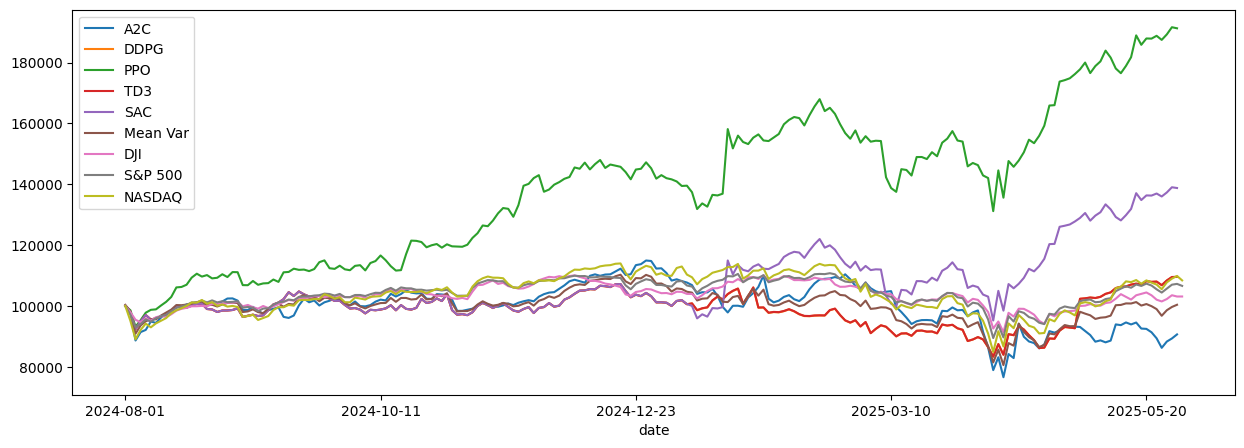

In [110]:
# Setting the figure size for the charts and plotting the performance charts of the trading strategies.
plt.rcParams["figure.figsize"] = (15,5)
plt.figure()
result.plot()

In [111]:
from pyfolio import timeseries
import pandas as pd

# List of strategies for which you want to generate statistics
strategies = ['A2C', 'DDPG', 'PPO', 'TD3', 'SAC', "Mean Var", "DJI", "S&P 500", 'NASDAQ']

for strategy in strategies:
    column_name = f'{strategy}'
    if column_name in result.columns:
        # Calculating daily returns from portfolio values
        result[f'{strategy}_returns'] = result[column_name].pct_change()

/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/3752157917.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  result[f'{strategy}_returns'] = result[column_name].pct_change()
/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/3752157917.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  result[f'{strategy}_returns'] = result[column_name].pct_change()
/var/folders/73/kd4kmxp15vvcmt5tvqc6qyt80000gn/T/ipykernel_47556/3752157917.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fil

In [112]:
result.head()

,A2C,DDPG,PPO,TD3,SAC,Mean Var,DJI,S&P 500,NASDAQ,A2C_returns,DDPG_returns,PPO_returns,TD3_returns,SAC_returns,Mean Var_returns,DJI_returns,S&P 500_returns,NASDAQ_returns
date,,,,,,,,,,,,,,,,,,
2024-08-01,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100371.513006,100000.000000,100000.000000,100000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-02,97577.254809,97933.168428,98585.194606,97933.168428,97933.168428,98210.501932,97943.071056,97088.937826,95089.371341,-0.024227,-0.020668,-0.014148,-0.020668,-0.020668,-0.021530,-0.020569,-0.029111,-0.049106
2024-08-05,88650.555895,92406.333925,93181.703435,92393.627182,92393.627182,90908.484092,95452.327131,93017.138127,89037.820526,-0.091483,-0.056435,-0.054810,-0.056565,-0.056565,-0.074351,-0.025431,-0.041939,-0.063641
2024-08-06,91414.008883,94973.040743,95339.766149,94967.834000,94967.834000,93591.078408,94670.322190,94015.357410,92147.862839,0.031172,0.027776,0.023160,0.027861,0.027861,0.029509,-0.008193,0.010732,0.034929
2024-08-07,92126.004809,97020.724215,97784.068059,97020.357468,97020.357468,94966.064725,95877.330439,95581.129685,94193.250701,0.007789,0.021561,0.025638,0.021613,0.021613,0.014691,0.012750,0.016654,0.022197


### We calculate returns based on the selected strategy

In [113]:
# We assume that the result DataFrame already contains portfolio values for each strategy
for strategy in strategies:
    # Check if the strategy exists in the DataFrame
    if f'{strategy}_returns' in result.columns:
        # Extract daily returns for the current strategy
        returns = result[f'{strategy}_returns'].dropna()
        returns.index = pd.to_datetime(returns.index)

        # Calculate performance statistics for the current strategy
        perf_stats = timeseries.perf_stats(returns=returns, factor_returns=None, positions=None, transactions=None, turnover_denom="AGB")

        # Print performance statistics
        print(f"==============Strategy Stats ({strategy})==============")
        print(perf_stats)
        print("\n")
    else:
        print(f"Strategy {strategy} not found in results.\n")


==============Strategy Stats (A2C)==============
Annual return         -0.112656
Cumulative returns    -0.093514
Annual volatility      0.373640
Sharpe ratio          -0.134523
Calmar ratio          -0.337440
Stability              0.140824
Max drawdown          -0.333856
Omega ratio            0.972989
Sortino ratio         -0.189532
Skew                   0.415924
Kurtosis               8.556305
Tail ratio             0.859003
Daily value at risk   -0.047274
dtype: float64


==============Strategy Stats (DDPG)==============
Annual return          0.117568
Cumulative returns     0.095604
Annual volatility      0.287927
Sharpe ratio           0.528241
Calmar ratio           0.529137
Stability              0.033642
Max drawdown          -0.222188
Omega ratio            1.105439
Sortino ratio          0.792381
Skew                   0.749115
Kurtosis               7.119521
Tail ratio             0.916858
Daily value at risk   -0.035672
dtype: float64


==============Strategy Stats (PPO)=

### We plot cumulative returns for each strategy

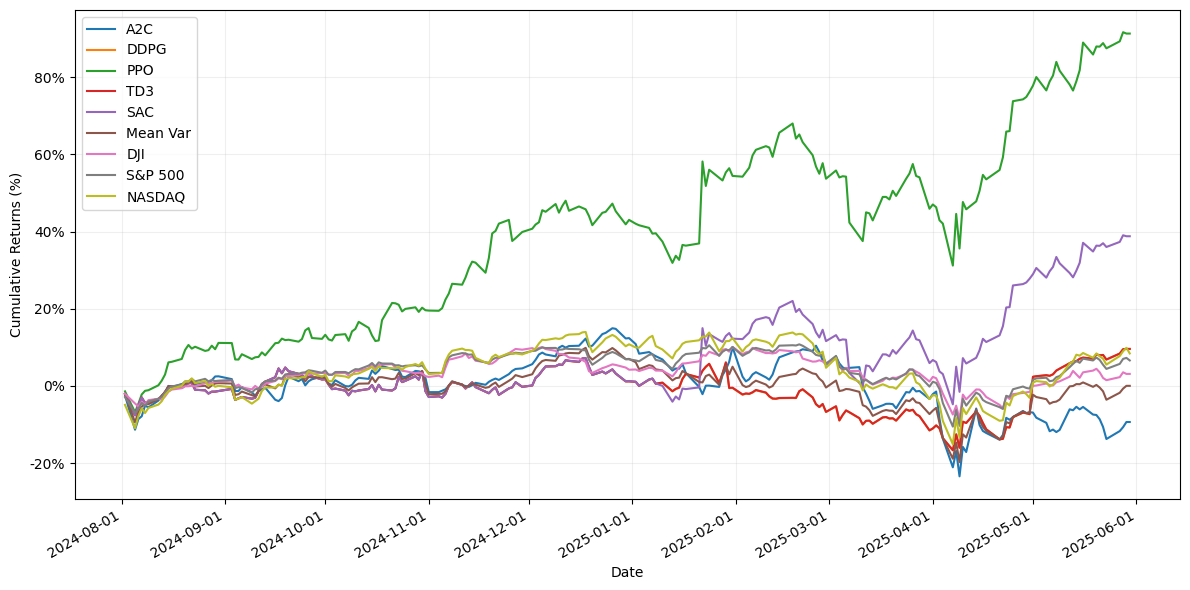

In [114]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# Setting the figure size for the plot
plt.figure(figsize=(12, 6))

# Iterating through each strategy and plotting its cumulative returns
for strategy in strategies:
    if f'{strategy}_returns' in result.columns:
        # Make sure dates are properly parsed
        result.index = pd.to_datetime(result.index)
        
        # Extracting daily returns for the current strategy and converting to decimal format if necessary
        returns = result[f'{strategy}_returns'].dropna() + 1  # Adds 1 for using cumprod()
        
        # Calculating cumulative returns and converting to percentage
        cumulative_returns = (returns.cumprod() - 1) * 100  # Convert to percentage
        
        # Plotting cumulative returns with original colors
        plt.plot(cumulative_returns.index, cumulative_returns, label=strategy)

# Format y-axis as percentages
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
plt.ylabel('Cumulative Returns (%)')
plt.xlabel('Date')

# Format x-axis dates
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Make sure dates are in the correct format and rotated
plt.gcf().autofmt_xdate()

# Adding title and legend
#plt.title('Cumulative Returns of DRL Strategies')
plt.legend(loc='upper left')

# Add grid with light gray color
plt.grid(True, linestyle='-', alpha=0.2)

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Displaying the plot
plt.show()

### Saving results to CSV

In [119]:
import pickle

# # For ppo
# with open('results/aronrl_0.001_df_account_value_ppo.pkl', 'wb') as f:
#     pickle.dump(df_account_value_ppo, f)

# with open('results/aronrl_0.001_df_actions_ppo.pkl', 'wb') as f:
#     pickle.dump(df_actions_ppo, f)
    
# For a2c
""" with open('results//aronrl_0.001_df_account_value_a2c.pkl', 'wb') as f:
    pickle.dump(df_account_value_a2c, f) """

with open('results//aronrl_0.001_df_actions_a2c.pkl', 'wb') as f:
    pickle.dump(df_actions_a2c, f)

# For sac
""" with open('results/aronrl_0.001_df_account_value_sac.pkl', 'wb') as f:
    pickle.dump(df_account_value_sac, f) """

with open('results/aronrl_0.001_df_actions_sac.pkl', 'wb') as f:
    pickle.dump(df_actions_sac, f)

# For ddpg
""" with open('results//aronrl_0.001_df_account_value_ddpg.pkl', 'wb') as f:
    pickle.dump(df_account_value_ddpg, f) """

with open('results//aronrl_0.001_df_actions_ddpg.pkl', 'wb') as f:
    pickle.dump(df_actions_ddpg, f)

# For td3
""" with open('results/aronrl_0.001_df_account_value_td3.pkl', 'wb') as f:
    pickle.dump(df_account_value_td3, f) """

with open('results/aronrl_0.001_df_actions_td3.pkl', 'wb') as f:
    pickle.dump(df_actions_td3, f)

""" # For mean var
with open('results/aronrl_mean_var.pkl', 'wb') as f:
    pickle.dump(MVO_result, f)

# For dji
with open('results/aronrl_dji.pkl', 'wb') as f:
    pickle.dump(dji, f) """

" # For mean var\nwith open('results/aronrl_mean_var.pkl', 'wb') as f:\n    pickle.dump(MVO_result, f)\n\n# For dji\nwith open('results/aronrl_dji.pkl', 'wb') as f:\n    pickle.dump(dji, f) "

In [118]:
# For nasdaq
with open('results/aronrl_nas.pkl', 'wb') as f:
    pickle.dump(nas, f)